# Learning a pricing rule

I train a model to choose prices from saved decisions, then compare its revenue with simple benchmarks.

This is **offline reinforcement learning**: the training data stays fixed, and the learner cannot try new prices while fitting. The simulator is used separately to evaluate finished policies.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

# Find the project even when this notebook is opened from its version folder.
ROOT = Path.cwd()
while not (ROOT / 'data/source.json').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Open this notebook inside the hotel pricing project')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'versions/Sep_25_v1'))  # Frozen v1 implementation.

from hotel_pricing.cql import TrainingConfig, bellman_target, make_network, train
from hotel_pricing.environment import load_config
from hotel_pricing.offline_data import load_dataset

config = load_config()
DATA = ROOT / 'data/simulated/hotel_v1'
RUN = ROOT / 'outputs/cql/run_v1'
OUT = ROOT / 'outputs/cql'
result = json.loads((RUN / 'results.json').read_text())
manifest_path = ROOT / 'data/simulated/hotel_v1/manifest.json'
assert hashlib.sha256(manifest_path.read_bytes()).hexdigest() == result['dataset_manifest_sha256']
results = pd.DataFrame(result['results']).set_index('policy')
with np.load(RUN / 'policies.npz', allow_pickle=False) as saved:
    policies = dict(saved)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Predict the value of each price

A **Q-value** estimates total future revenue from choosing a price now and following the learned rule afterward.

The network receives time and inventory and returns five values, one per price. The policy chooses the highest value. I scale time by 330, inventory by 10, and rewards by 90; evaluation uses the original revenue units.

The network has two hidden layers of 64 units.

In [2]:
make_network(len(result['config']['prices']))

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=5, bias=True)
)

## 2. Learn from a saved decision

For each transition, the model learns toward:

`target = today's reward + best predicted value at the next state`

At the end of an episode, the future term is zero. I use `gamma = 1`, so later revenue counts equally. A **target network**, copied periodically from the model, supplies the future predictions.

The example uses made-up learning values: reward 1 plus future value 5 gives 6; an ending transition with no sale gives 0.

In [3]:
# Two made-up transitions, only to show the target calculation.
rewards = torch.tensor([1.0, 0.0])
episode_ended = torch.tensor([False, True])
next_price_values = torch.tensor([
    [2.0, 3.0, 5.0, 4.0, 1.0],
    [2.0, 3.0, 5.0, 4.0, 1.0],
])
targets = bellman_target(rewards, episode_ended, next_price_values)
print('Targets:', targets.tolist())  # [6.0, 0.0]

Targets: [6.0, 0.0]


The targets are **6 and 0**. The ending flag removes the future-value term for the second transition.

**The CQL penalty**

An action with little supporting data can receive an unrealistically high Q-value. CQL discourages high values relative to those of recorded actions:

`loss = prediction error + 0.1 × CQL penalty`

The penalty is `mean(logsumexp(all action values) - recorded action value)`. `logsumexp` combines the values with more weight on larger ones. This encourages caution but cannot supply missing experience.

I use a discrete version of [Conservative Q-Learning](https://arxiv.org/abs/2006.04779).

## 3. Train the model

Each update samples saved transitions, calculates the loss, and adjusts the weights. The target network is refreshed periodically.

I first run 10 updates to check the training call. This practice model is separate from the full experiment and is not used in the revenue comparison.

In [4]:
training_records = load_dataset(DATA, 'train')
validation_records = load_dataset(DATA, 'validation')
practice_settings = TrainingConfig(updates=10, log_every=10)

practice_model, practice_history = train(
    training_records,
    validation_records,
    config,
    settings=practice_settings,
    seed=0,
)
print('Practice updates completed:', practice_history[-1]['update'])
print('This practice model is separate from the saved full experiment.')

Practice updates completed: 10
This practice model is separate from the saved full experiment.


The short run checks that saved transitions can pass through the training loop. Ten updates do not tell us whether the resulting prices are useful.

**The full experiment**

I read the saved run with these fixed settings:

- 20,000 updates per seed, 256 transitions per batch.
- Training seeds 0, 1, and 2, sharing the same dataset.
- Adam learning rate 0.0003 and CQL weight 0.1.
- Target network refreshed every 100 updates.

Every final checkpoint is retained. The seeds vary initialization and batch sampling, not the collected data.

The plots show validation prediction error and the training CQL penalty. Neither measures policy revenue.

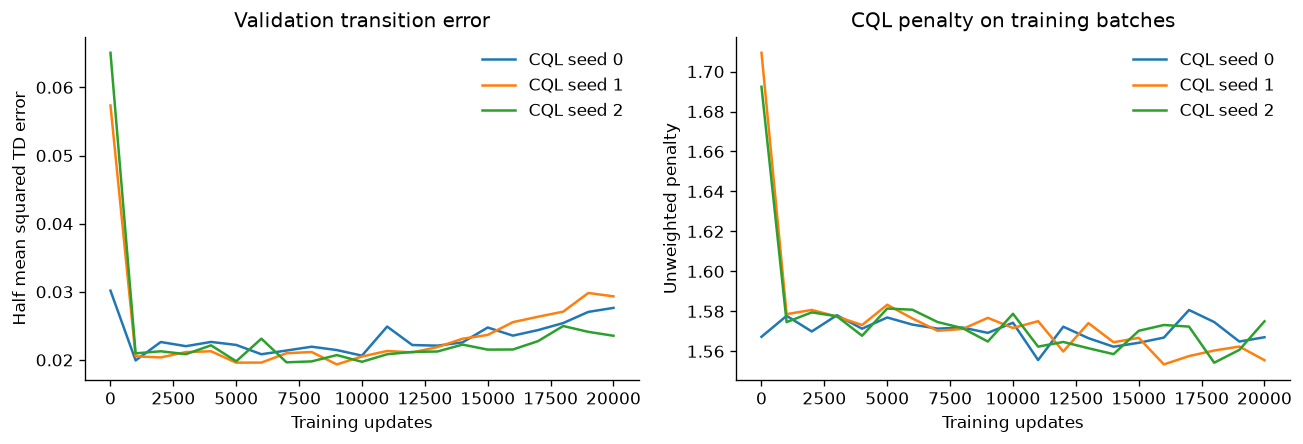

Final test transition error — a diagnostic, not a revenue estimate:
CQL seed 0: 0.0296
CQL seed 1: 0.0305
CQL seed 2: 0.0248


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, rows in result['history'].items():
    history = pd.DataFrame(rows)
    axes[0].plot(history['update'], history['validation_td_loss'], label=name)
    axes[1].plot(history['update'], history['batch_cql_penalty'], label=name)
axes[0].set(title='Validation transition error', ylabel='Half mean squared TD error')
axes[1].set(title='CQL penalty on training batches', ylabel='Unweighted penalty')
for ax in axes:
    ax.set_xlabel('Training updates')
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / 'training_curves.png')
plt.show()

print('Final test transition error — a diagnostic, not a revenue estimate:')
for name, metrics in result['test_diagnostics'].items():
    print(f"{name}: {metrics['td_loss']:.4f}")

Prediction error drops early and then levels off or rises slightly. This describes fitting, but does not establish that the policy earns more.

## 4. Compare revenue

I evaluate each frozen policy on 1,000 fresh episodes with matched sale random numbers. No model weights change.

- **Behavior policy:** the random mix used for collection.
- **Reference price:** always charge 90.
- **Best fixed price:** the best constant price under the known demand model.
- **Optimum:** the best price at each state, calculated backward using that model.

The last two benchmarks know the sale probabilities; the learner does not. Bars show simulated means with approximate 95% intervals. Dots show exact expected revenue under the assumed model.

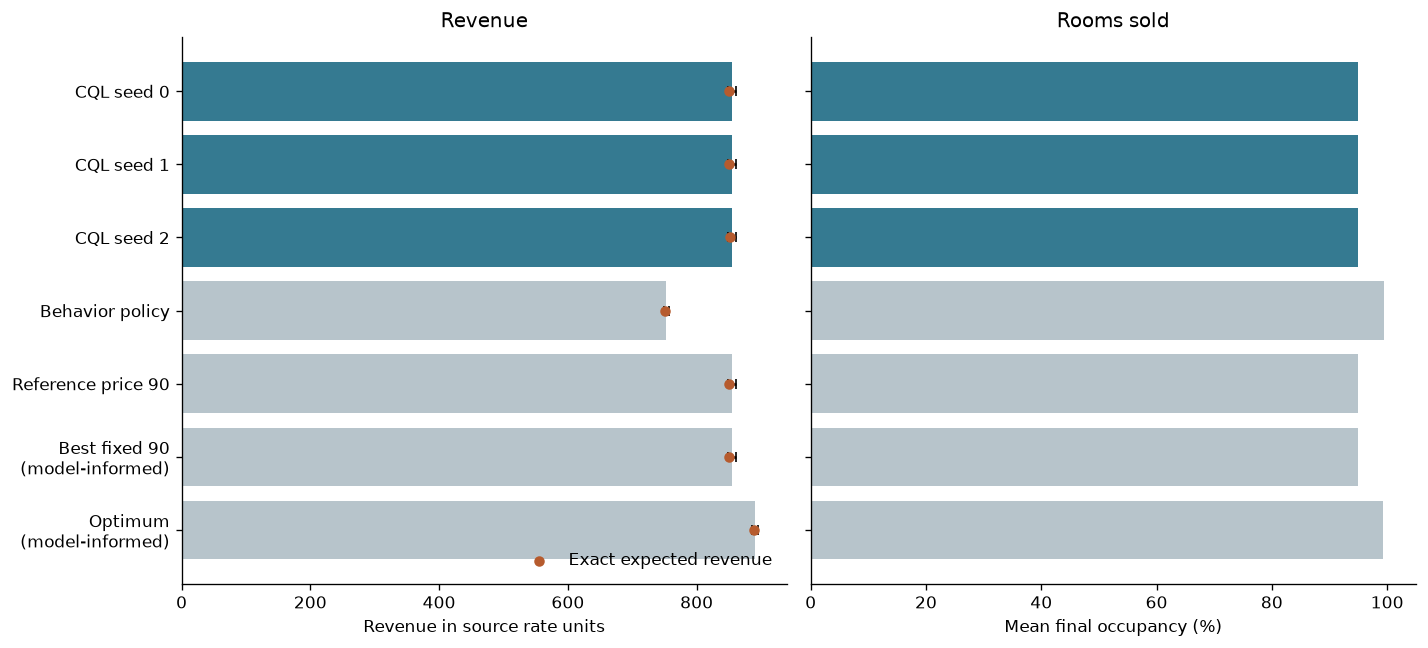

CQL seed 0: exact revenue 851.00; gap to optimum 4.2%; episode revenue SD 103.53
CQL seed 1: exact revenue 851.00; gap to optimum 4.2%; episode revenue SD 103.53
CQL seed 2: exact revenue 851.08; gap to optimum 4.2%; episode revenue SD 103.22
Behavior policy: exact revenue 750.33; gap to optimum 15.5%; episode revenue SD 61.55
Reference price 90: exact revenue 851.00; gap to optimum 4.2%; episode revenue SD 103.53
Best fixed 90 (model-informed): exact revenue 851.00; gap to optimum 4.2%; episode revenue SD 103.53
Optimum (model-informed): exact revenue 888.41; gap to optimum 0.0%; episode revenue SD 70.19


In [6]:
labels = []
for name in results.index:
    labels.append(name.replace(' (model-informed)', '\n(model-informed)'))
y = np.arange(len(results))
colors = []
for name in results.index:
    if name.startswith('CQL'):
        colors.append('#357a91')
    else:
        colors.append('#b7c4cb')
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
axes[0].barh(y, results['mean_revenue'], color=colors,
             xerr=results['mean_revenue_ci95_half_width'], capsize=3)
axes[0].scatter(results['exact_revenue'], y, color='#b65b2e', s=28, zorder=3, label='Exact expected revenue')
axes[0].set(yticks=y, yticklabels=labels, xlabel='Revenue in source rate units', title='Revenue')
axes[0].legend(frameon=False, loc='lower right')
axes[0].invert_yaxis()
axes[1].barh(y, results['mean_occupancy'] * 100, color=colors)
axes[1].set(xlabel='Mean final occupancy (%)', xlim=(0, 105), title='Rooms sold')
fig.tight_layout()
fig.savefig(OUT / 'policy_comparison.png')
plt.show()

for name, row in results.iterrows():
    print(f"{name}: exact revenue {row['exact_revenue']:.2f}; "
          f"gap to optimum {row['optimality_gap_percent']:.1f}%; "
          f"episode revenue SD {row['episode_revenue_sd']:.2f}")

In [7]:
# Summarize all three seeds, without choosing a winner.
cql = results.loc[results.index.str.startswith('CQL')]
smallest_revenue = cql['exact_revenue'].min()
largest_revenue = cql['exact_revenue'].max()
smallest_gap = cql['optimality_gap_percent'].min()
largest_gap = cql['optimality_gap_percent'].max()

print(f'CQL expected revenue: {smallest_revenue:.2f} to {largest_revenue:.2f}')
print(f'Gap to optimum: {smallest_gap:.1f}% to {largest_gap:.1f}%')
print('Gap means how far revenue is below the model-informed optimum.')

CQL expected revenue: 851.00 to 851.08
Gap to optimum: 4.2% to 4.2%
Gap means how far revenue is below the model-informed optimum.


CQL earns about **851**, compared with **750** for the behavior policy and **888** for the optimum. The best fixed price is 90. Seeds 0 and 1 use that same policy; seed 2 gains only about **0.08** in exact expected revenue.

CQL improves on random collection but shows no meaningful benefit over fixed pricing. The remaining gap to the optimum is about **4.2%**. Price 90 being best depends on the chosen demand curve, inventory, and price menu; it is not a real-hotel finding.

The 0.08 difference is a model-based expectation, not a statistically significant gain inferred from the plotted intervals. Matched episodes require paired comparisons.

## 5. Inspect the pricing rules

Each cell shows a price at one time-and-inventory state. Time runs from 330 on the left to 1 on the right; lower rows have fewer rooms. Blank states are unreachable.

A colored cell shows a decision, not whether that state had enough training data.

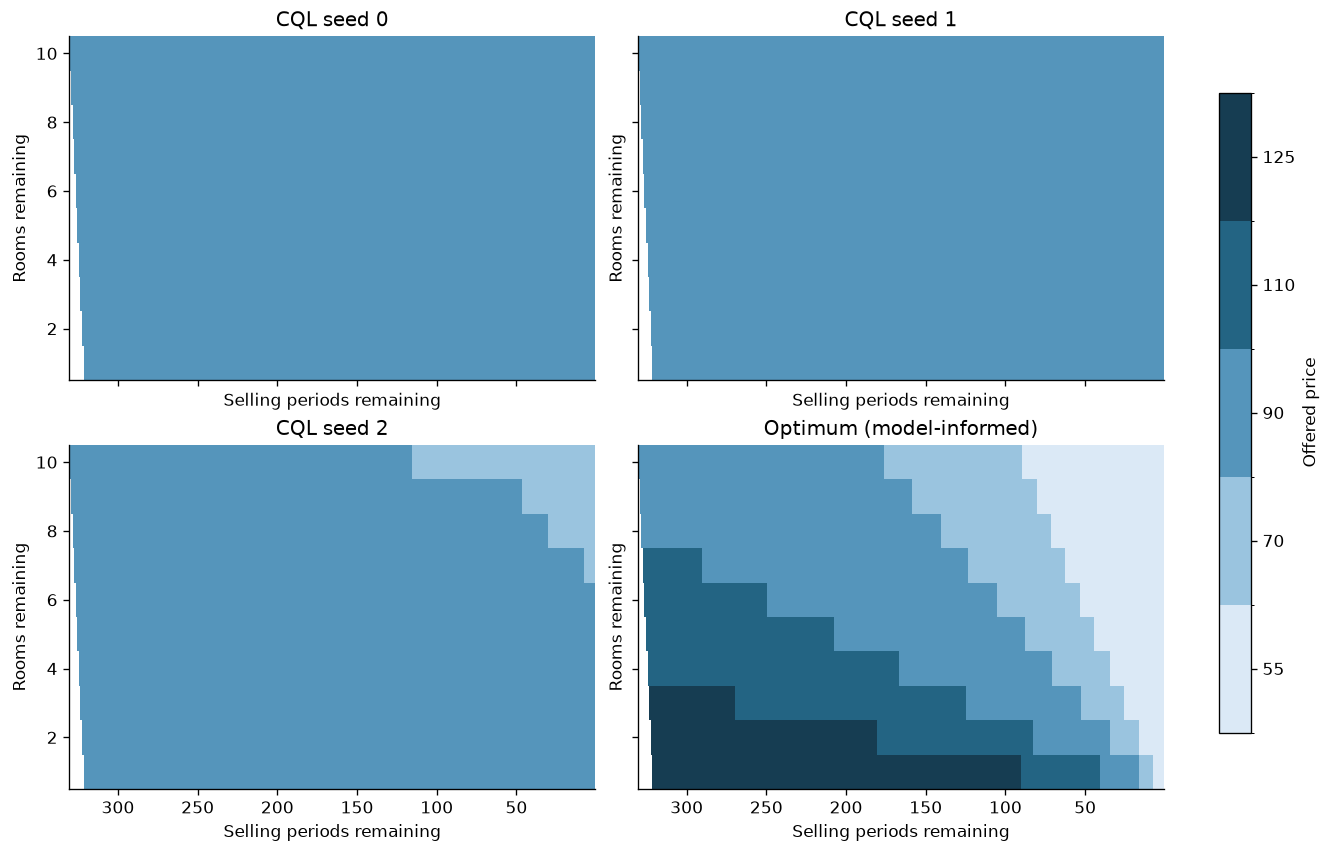

In [8]:
prices = np.asarray(result['config']['prices'])
horizon, capacity = result['config']['horizon'], result['config']['capacity']
t, c = np.meshgrid(np.arange(1, horizon + 1), np.arange(1, capacity + 1), indexing='ij')
rooms_already_sold = capacity - c
days_already_used = horizon - t
unreachable = rooms_already_sold > days_already_used  # At most one sale per day.
cmap = ListedColormap(['#dbe9f6', '#9ac4df', '#5595bb', '#236483', '#163d52'])
norm = BoundaryNorm(np.arange(-0.5, len(prices) + 0.5), len(prices))
names = list(cql.index) + ['Optimum (model-informed)']
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, layout='constrained')
for ax, name in zip(axes.flat, names):
    choices = np.ma.array(policies[name][1:, 1:], mask=unreachable)
    picture = ax.imshow(choices.T, origin='lower', aspect='auto', interpolation='nearest', cmap=cmap, norm=norm,
                        extent=[0.5, horizon + 0.5, 0.5, capacity + 0.5])
    ax.set(title=name, xlabel='Selling periods remaining', ylabel='Rooms remaining')
    ax.set_xlim(horizon + 0.5, 0.5)
colorbar = fig.colorbar(picture, ax=axes, ticks=np.arange(len(prices)), shrink=0.85)
colorbar.ax.set_yticklabels(prices)
colorbar.set_label('Offered price')
fig.savefig(OUT / 'policy_maps.png')
plt.show()

The optimum raises prices when rooms are scarce and time remains, then lowers them when many rooms remain near arrival. CQL seeds 0 and 1 stay at 90. Seed 2 lowers prices in some high-inventory states, with little effect on expected revenue.

The first model mainly learns a good fixed price. Data coverage, the CQL penalty, network fitting, and training budget could explain the gap, but this experiment does not separate their effects. These results apply to the assumed simulator, not a real hotel.